# Exercise 4.A Introduction to Linear Regression

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split 

## Lab 1 
### Running a sample script

In [4]:
# Sample dataset: hours studied vs. exam score
data = {
    'hours_studied': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    'exam_score':    [52, 55, 60, 65, 68, 72, 75, 80, 85, 90]
}
df = pd.DataFrame(data)

# Step 1: Define features (X) and target (y)
X = df[['hours_studied']]   # 2D: double brackets give a DataFrame, not a Series
y = df['exam_score']        # 1D: single brackets give a Series

# Step 2: Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Step 3: Create the model and fit it to training data
model = LinearRegression()
model.fit(X_train, y_train)

print('Model trained successfully.')

Model trained successfully.


### Working through the sample script

In [5]:
print(f'\nSlope (coefficient): {model.coef_[0]:.2f}')
print(f'Intercept: {model.intercept_:.2f}')


Slope (coefficient): 4.10
Intercept: 47.68


In [6]:
y_pred = model.predict(X_test)
print('Actual scores: ', list(y_test))
print('Predicted scores:', list(y_pred.round(1)))

Actual scores:  [85, 55]
Predicted scores: [np.float64(84.6), np.float64(55.9)]


In [7]:
r_squared = model.score(X_test, y_test)
print(f'R² score: {r_squared:.3f}')

R² score: 0.998


**What does the R² score mean?**

The R² (coefficient of determination) measures the proportion of variance in the target variable (exam score) that is explained by the feature (hours studied). 
A score of 1.0 means the model perfectly explains all variation; a score of 0 means it explains none. 
In this example the score is very close to 1.0, indicating that hours studied is an excellent predictor of exam score and almost all of the variation in scores is captured by the linear relationship.

C:\Users\malaikatariq\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


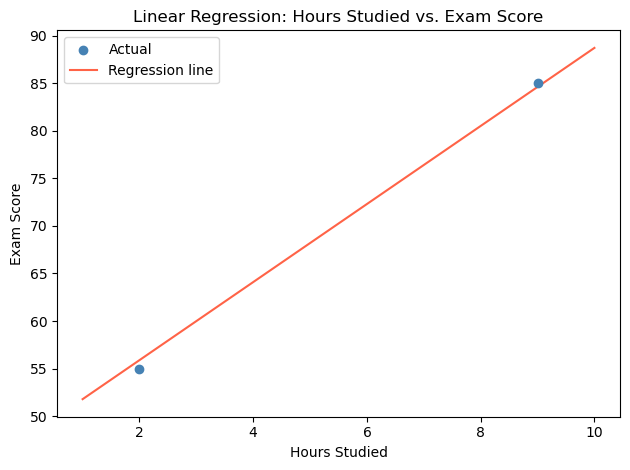

In [9]:
# Scatter plot: actual test data points 
plt.scatter(X_test, y_test, color='steelblue', label='Actual', zorder=3)

# Line: model predictions across the full range of X 
x_range = np.linspace(
    X['hours_studied'].min(), 
    X['hours_studied'].max(),
    100
).reshape(-1, 1) 
y_line = model.predict(x_range)
plt.plot(x_range, y_line, color='tomato', label='Regression line')

plt.xlabel('Hours Studied') 
plt.ylabel('Exam Score') 
plt.title('Linear Regression: Hours Studied vs. Exam Score') 
plt.legend() 
plt.tight_layout() 
plt.show()

**How closely do the actual data points follow the regression line?**

The actual data points (blue) lie almost perfectly along the red regression line, confirm the perfect linear relationship between hours studied and exam score. There is very little scatter around the line, which matches the high R² score we observed.

## Lab 2 
### Building your own model

In [11]:
ad_data = { 
    'monthly_ad_spend': [500, 1000, 1500, 2000, 2500, 3000, 3500, 4000, 4500, 5000, 5500, 6000, 6500, 7000, 7500, 8000, 8500, 9000, 9500, 10000],
    'monthly_revenue': [4200, 5100, 6800, 7400, 8900, 9200, 10500, 11800, 12400, 13100, 14200, 15600, 15900, 17200, 18100, 19400, 20200, 21500, 22100, 23800]
}

df_ads = pd.DataFrame(ad_data)
df_ads

,monthly_ad_spend,monthly_revenue
0,500,4200
1,1000,5100
2,1500,6800
3,2000,7400
4,2500,8900
5,3000,9200
6,3500,10500
7,4000,11800
8,4500,12400
9,5000,13100


In [12]:
X2 = df_ads[['monthly_ad_spend']]
y2 = df_ads['monthly_revenue']

print('Shape of X2:', X2.shape)
print('Shape of y2:', y2.shape)

Shape of X2: (20, 1)
Shape of y2: (20,)


In [14]:
X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2, test_size =0.2, random_state=42
)

In [15]:
model2 = LinearRegression()
model2.fit(X2_train, y2_train)
print('Model tarined successfully.')

Model tarined successfully.


In [17]:
slope = model2.coef_[0]
intercept = model2.intercept_

print(f'Slope: {slope:.2f}')
print(f'Intercept: {intercept:.2f}')
print()

# Interpretation: for each additional $1 spent, the predicted monthly revenue increases by $1.96

Slope: 1.96
Intercept: 3625.89



### Making predictions and evaluating the model

In [18]:
y2_pred = model2.predict(X2_test)

comparison = pd.DataFrame({
    'Actual Revenue': list(y2_test),
    'Predicted Revenue': [round(v, 2) for v in y2_pred]
})
print(comparison.to_string(index=False))

 Actual Revenue  Predicted Revenue
           4200            4603.85
          21500           21229.03
          19400           19273.13
           5100            5581.80


In [19]:
r2_ads = model2.score(X2_test, y2_test)
print(f'R² score: {r2_ads:.3f}')

R² score: 0.998


**R² interpretation**

An R² score close to 1.0 indicates that the model explains nearly all the variation in monthly revenue through monthly ad spend alone, so the model is an excellent fit. 
The percentage of variance in revenue explained by ad spend is approximately R² × 100% = 99.8% (R²=0.998).

### Visualizing the results

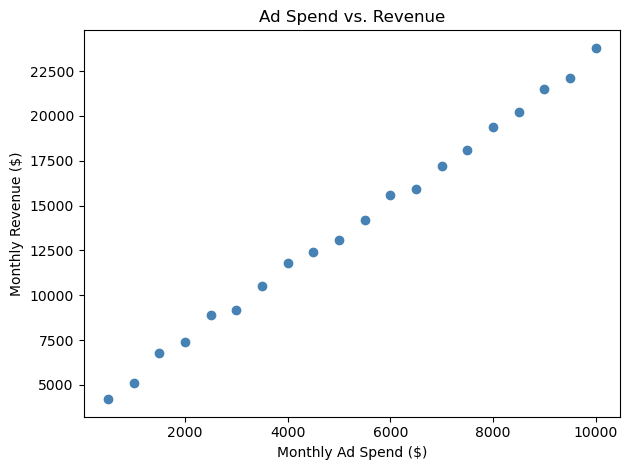

In [21]:
plt.scatter(X2, y2, color='steelblue')
plt.xlabel('Monthly Ad Spend ($)')
plt.ylabel('Monthly Revenue ($)')
plt.title('Ad Spend vs. Revenue')
plt.tight_layout()
plt.show()

C:\Users\malaikatariq\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


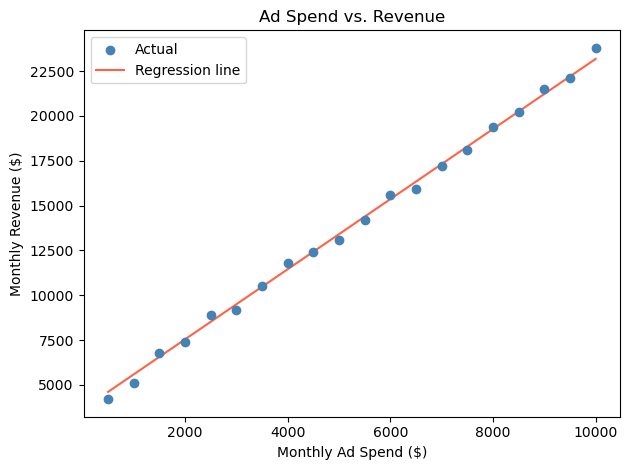

In [25]:
plt.scatter(X2, y2, color='steelblue', label='Actual', zorder=3)

x2_range = np.linspace(
    X2['monthly_ad_spend'].min(),
    X2['monthly_ad_spend'].max(),
    100
).reshape(-1, 1)

y2_line = model2.predict(x2_range)
plt.plot(x2_range, y2_line, color='tomato', label='Regression line')

plt.xlabel('Monthly Ad Spend ($)')
plt.ylabel('Monthly Revenue ($)')
plt.title('Ad Spend vs. Revenue')
plt.legend()
plt.tight_layout()
plt.show()

**Reflection**

The regression line tracks the data points closely, with only minor deviations. This visual confirmation aligns with the high R² score: the linear model captures the relationship between ad spend and revenue very well.